# Hall effect 

In [6]:
#======= librerie =============#

import numpy as np
import pandas as pd
from scipy.interpolate import interp1d
%matplotlib inline

print("\nLibrerie caricate correttamente\n")


Librerie caricate correttamente



In [19]:
#======== definizioni ==========#

# =========================================================
# 1. FUNZIONI DI CARICAMENTO (Gestiscono virgole o punti e virgola)
# =========================================================
def load_csv_data(filepath):

    df = pd.read_csv(filepath, sep= ";", decimal=',', header = None)
    
    # Assumiamo che la colonna 0 sia B (o T) e la colonna 1 sia rho o RH
    x = df.iloc[:, 0].values.astype(float)
    y = df.iloc[:, 1].values.astype(float)
    
    # Ordiniamo in base a B crescente (fondamentale per le interpolazioni)
    sort_idx = np.argsort(x)
    return x[sort_idx], y[sort_idx]

# =========================================================
# 2. FUNZIONI FISICHE (Conversioni e Calcoli)
# =========================================================
def get_MR(rho_array):
    """Calcola la Magnetoresistenza MR = (rho(B) - rho(0)) / rho(0)"""
    rho_0 = rho_array[0] # Prende il valore a campo più basso (idealmente B=0)
    return (rho_array - rho_0) / rho_0

def get_rho_xy(RH_array, B_array, factor=0.1):
    """
    Calcola rho_xy = R_H * B.
    Se R_H è in mm^3/C e B in Tesla, il fattore 0.1 restituisce muOhm*cm.
    """
    return RH_array * B_array * factor

# =========================================================
# 3. LA FUNZIONE "MASTER" (Estrapola e Allinea tutto)
# =========================================================
def process_hall_dataset(file_rho, file_RH):
    """
    Prende in pasto i percorsi dei file rho(B) e RH(B) per una data T.
    Allinea R_H sull'asse B di rho(B), e restituisce tutte le grandezze pronte per i fit.
    """
    # 1. Caricamento dati grezzi R_H
    df_RH = pd.read_csv(file_RH, sep=";", decimal=',', header=None)
    df_RH_clean = df_RH.groupby(0).mean().reset_index() # Ottima mossa per i duplicati!
    
    B_RH = df_RH_clean.iloc[:, 0].values.astype(float)
    RH_raw = df_RH_clean.iloc[:, 1].values.astype(float)
    
    # 2. Caricamento dati grezzi Rho
    df_rho = pd.read_csv(file_rho, sep=";", decimal=',', header=None)
    df_rho_clean = df_rho.groupby(0).mean().reset_index()
    
    B_rho = df_rho_clean.iloc[:, 0].values.astype(float)
    rho_xx = df_rho_clean.iloc[:, 1].values.astype(float) # <-- CORRETTO IL NOME QUI!
    
    if B_rho is None or B_RH is None:
        return None
    
    # 3. Interpolazione di R_H sui punti di campo magnetico B_rho
    RH_interp_func = interp1d(B_RH, RH_raw, kind='cubic', fill_value="extrapolate")
    RH_aligned = RH_interp_func(B_rho)
    
    # 4. Calcolo Grandezze Fisiche
    MR = get_MR(rho_xx)
    rho_xy = get_rho_xy(RH_aligned, B_rho, factor=0.1)
    
    # 5. Calcolo Cotangente dell'Angolo di Hall (cot(theta_H) = rho_xx / rho_xy)
    with np.errstate(divide='ignore', invalid='ignore'):
        cot_theta_H = rho_xx / rho_xy
        cot_theta_H[B_rho == 0] = np.nan 
        
    results = pd.DataFrame({
        'B_Tesla': B_rho,
        'rho_xx': rho_xx,          
        'MR_adim': MR,             
        'RH_aligned': RH_aligned,  
        'rho_xy': rho_xy,          
        'cot_theta_H': cot_theta_H 
    })
    
    return results

In [25]:
# Imposta i percorsi corretti dei file (adatta il percorso se necessario)
file_rho_10K = "Data_sets/Nd-LSCO_p24/rho_Nd-LSCO_p24_10K.csv"
file_RH_10K  = "Data_sets/Nd-LSCO_p24/RH(B)_Nd-LSCO_p24_10K.csv"

# Magia: la funzione master fa tutto il lavoro sporco
df_10K = process_hall_dataset(file_rho_10K, file_RH_10K)

# Ora hai un Dataframe completo! Puoi plottare la cotangente di Hall:
import matplotlib.pyplot as plt

plt.plot(df_10K['B_Tesla'], df_10K['cot_theta_H'], 'o-', label="10 K")
plt.xlabel("Magnetic Field B (T)")
plt.ylabel(r"$\cot(\theta_H)$")
plt.legend()
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'Data_sets/Nd-LSCO_p24/RH(B)_Nd-LSCO_p24_10K.csv'

⚠️ Attenzione: File rho mancante per T = 1.5K. Lo salto.


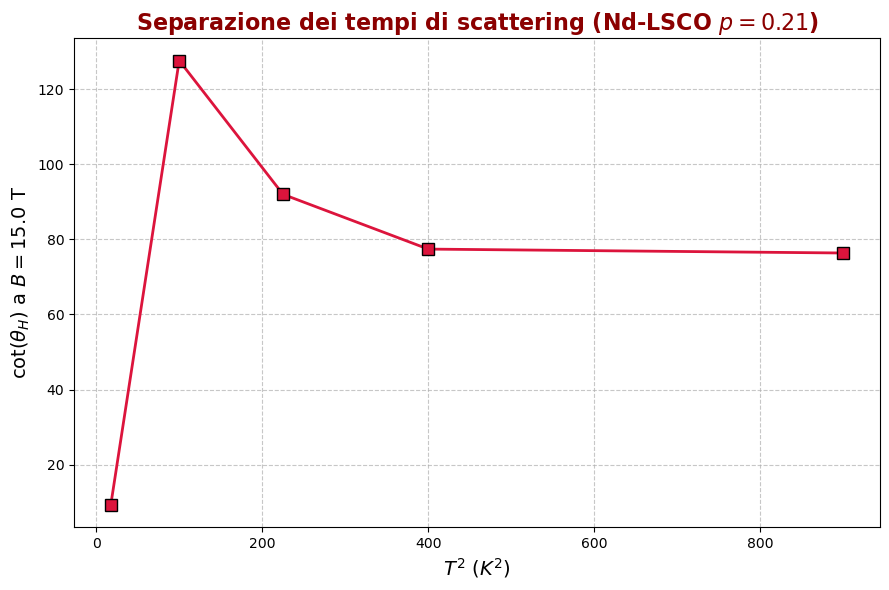

In [24]:
import matplotlib.pyplot as plt
import numpy as np
import os # <--- Ci serve per controllare se i file esistono!

# Lista delle temperature
T_list = [1.5, 4.2, 10, 15, 20, 30]

cot_theta_vs_T = []
T_validi = []

B_target = 15.0 

for T in T_list:
    file_rho = f"Data_sets/Nd-LSCO_p21/rho_Nd-LSCO_p21_{T:g}K.csv"
    file_RH  = f"Data_sets/Nd-LSCO_p21/RH(B)_Nd-LSCO_p21_{T:g}K.csv"
    
    # 🟢 PROTEZIONE: Controlliamo se ENTRAMBI i file esistono fisicamente
    if not os.path.exists(file_rho):
        print(f"⚠️ Attenzione: File rho mancante per T = {T}K. Lo salto.")
        continue
    if not os.path.exists(file_RH):
        print(f"⚠️ Attenzione: File RH mancante per T = {T}K. Lo salto.")
        continue
        
    # Se arriva qui, i file esistono e possiamo processarli in sicurezza
    df_T = process_hall_dataset(file_rho, file_RH)
    
    if df_T is not None and not df_T.empty:
        idx_B = (np.abs(df_T['B_Tesla'] - B_target)).argmin()
        cot_val = df_T['cot_theta_H'].iloc[idx_B]
        
        cot_theta_vs_T.append(cot_val)
        T_validi.append(T)

T_array = np.array(T_validi)
cot_array = np.array(cot_theta_vs_T)

# =========================================================
# IL PLOT DI ANDERSON: cot(theta_H) vs T^2
# =========================================================
if len(T_array) > 0:
    fig, ax = plt.subplots(figsize=(9, 6))

    ax.plot(T_array**2, cot_array, 's-', color='crimson', markersize=8, markeredgecolor='black', linewidth=2)

    ax.set_xlabel(r"$T^2 \ (K^2)$", fontsize=14)
    ax.set_ylabel(f"$\cot(\\theta_H)$ a $B={B_target}$ T", fontsize=14)
    ax.set_title("Separazione dei tempi di scattering (Nd-LSCO $p=0.21$)", fontsize=16, fontweight='bold', color='darkred')
    ax.grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()
else:
    print("❌ Nessun dato valido trovato per fare il plot!")